# Ideology Mapping Toolkit — Visual Tour

This notebook is a visual walkthrough of the 8-axis ideological scoring framework. It loads 100 pre-scored synthetic proposals and produces the key charts from the paper.

**No API keys needed.** All data is synthetic (hand-scored base values + Gaussian noise). To score your own proposals, see `prompts/README.md` and `docs/replication-guide.md`.

### The 8 Axes

| Axis | −100 pole | +100 pole |
|------|-----------|-----------|
| `aequitas_libertas` | Full redistribution | Individual freedom |
| `imperium_anarkhia` | Centralized authority | Decentralization |
| `universalism_particularism` | Universal rules | Group-specific policies |
| `market_collective_allocation` | Market allocation | Collective allocation |
| `inequality_acceptance_correction` | Inequality is natural | Inequality must be corrected |
| `individual_socialized_risk` | Individual bears risk | Risk pooled collectively |
| `progressivism_preservation` | Reform, change | Tradition, continuity |
| `technocracy_populism` | Expert-led governance | Popular-will primacy |

Each proposal gets a continuous score (−100 to +100) on all 8 axes. See `docs/axes.md` for the full rationale.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOOLKIT_ROOT = Path.cwd() if Path("cli.py").exists() else Path.cwd().parent
sys.path.insert(0, str(TOOLKIT_ROOT))

from analysis.label_io import AXES
from analysis.insights import category_centroids
from analysis.dimensionality import reconstruction_r2_all_subsets
from analysis.triangulation import evaluate_agreement
from analysis import visualize

# Load example data
labels = pd.read_parquet(TOOLKIT_ROOT / "data" / "examples" / "labels_clean.parquet")
items = pd.read_csv(TOOLKIT_ROOT / "data" / "examples" / "politikas_100.csv")

# Pre-compute for later cells
centroids = category_centroids(labels, items, category_col="category")
axis_cols = [c for c in labels.columns if c.startswith("axis_") and c.endswith("_mean")]
r2_all = reconstruction_r2_all_subsets(labels[axis_cols].dropna(), axis_cols=axis_cols, max_k=2)

n_valid = labels["valid"].sum() if "valid" in labels.columns else len(labels)
print(f"Loaded {len(labels)} proposals across {items['category'].nunique()} categories, scored on 8 axes.")
print(f"Valid items: {n_valid} / {len(labels)} (synthetic data — 100% expected, see data/examples/README.md)")

Loaded 100 proposals across 11 categories, scored on 8 axes.
Valid items: 100 / 100 (synthetic data — 100% expected, see data/examples/README.md)


## Axis Correlations

Are the 8 axes independent? The heatmap shows Pearson correlations. Strong correlations between axes suggest they capture overlapping information — the "equity cluster" (aequitas, market, inequality, risk) is highly redundant, while the "authority cluster" (imperium, technocracy, universalism) carries genuinely independent signal.

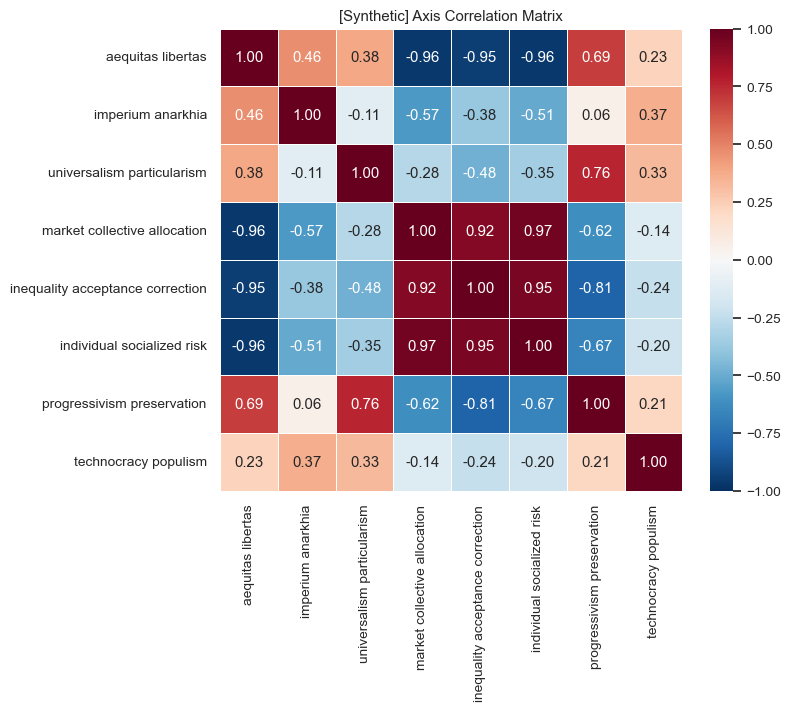

In [2]:
fig = visualize.correlation_heatmap(labels)
fig.axes[0].set_title("[Synthetic] Axis Correlation Matrix")
fig.set_size_inches(8, 7)
plt.show()

## Category Ideological Profiles

Each line connects a policy category's mean score across the 8 axes. Categories that occupy different regions of ideological space will have visibly different profiles — security proposals lean strongly statist while rights proposals lean universalist and reform-oriented.

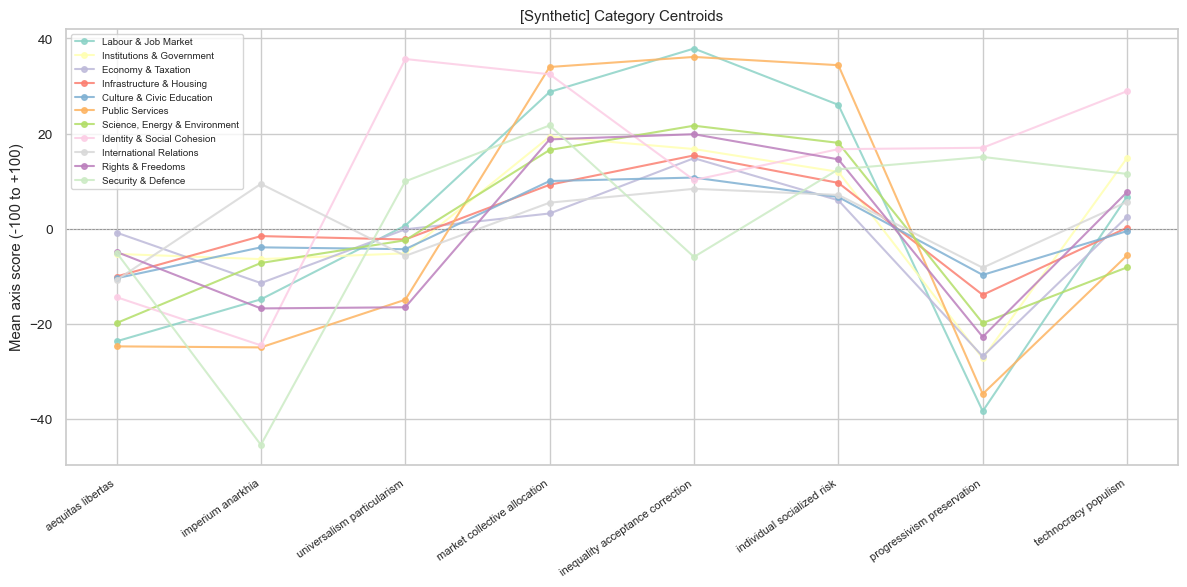

In [3]:
fig = visualize.category_centroids_line(centroids)
fig.axes[0].set_title("[Synthetic] Category Centroids")
fig.set_size_inches(12, 6)
plt.show()

## Dimensionality: How Much Signal Do Fewer Axes Capture?

The compression leaderboard ranks all 36 possible low-dimensional projections: 8 single-axis (1D) and 28 two-axis (2D) subsets, by how much of the full 8-axis structure they reconstruct (R² via Ridge regression).

This makes explicit what is lost when moving from a single left-right axis (the current standard) to a 2-axis framework, and from there to the full 8D space.

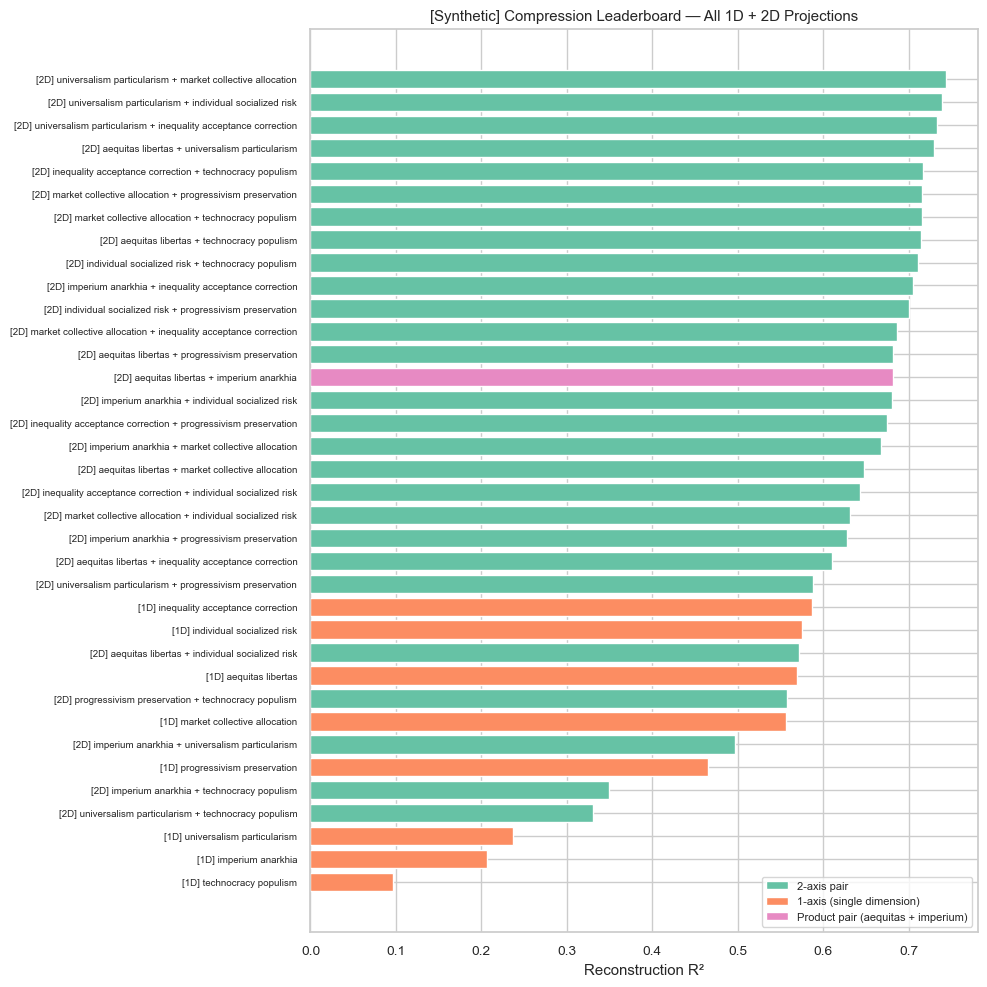

Product pair (aequitas + imperium): rank 14/36, R² = 0.682
Best single axis (inequality acceptance correction): rank 24/36, R² = 0.587
Gap: 2D product pair captures 9.6 pp more than the best 1D projection


In [4]:
# Build the combined 1D+2D leaderboard
short = lambda t: " + ".join(
    c.replace("_mean", "").replace("axis_", "").replace("_", " ") for c in t
)
r2_all["pair"] = r2_all["subset_axes"].apply(short)
r2_all["r2"] = r2_all["mean_r2"]
r2_plot = r2_all[["pair", "r2", "k"]].sort_values("r2", ascending=False).reset_index(drop=True)

# Color by k: 2D in main color, 1D entries highlighted
colors = ["#66c2a5" if k == 2 else "#fc8d62" for k in r2_plot["k"]]

# Find product pair
pp_mask = r2_plot["pair"].str.contains("aequitas libertas") & r2_plot["pair"].str.contains("imperium anarkhia")
for idx in r2_plot[pp_mask].index:
    colors[idx] = "#e78ac3"  # highlight pink

fig, ax = plt.subplots(figsize=(10, 10))
r2_sorted = r2_plot.sort_values("r2", ascending=True)
colors_sorted = [colors[i] for i in r2_sorted.index]

bars = ax.barh(range(len(r2_sorted)), r2_sorted["r2"], color=colors_sorted, edgecolor="white")
ax.set_yticks(range(len(r2_sorted)))
k_labels = [f"[{int(row['k'])}D] {row['pair']}" for _, row in r2_sorted.iterrows()]
ax.set_yticklabels(k_labels, fontsize=7)
ax.set_xlabel("Reconstruction R²")
ax.set_title("[Synthetic] Compression Leaderboard — All 1D + 2D Projections")

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#66c2a5", label="2-axis pair"),
    Patch(facecolor="#fc8d62", label="1-axis (single dimension)"),
    Patch(facecolor="#e78ac3", label="Product pair (aequitas + imperium)"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="lower right")
fig.set_tight_layout(True)
plt.show()

# Print key ranks
pp_row = r2_plot[pp_mask].iloc[0]
pp_rank = r2_plot[pp_mask].index[0] + 1
best_1d = r2_plot[r2_plot["k"] == 1].iloc[0]
best_1d_rank = r2_plot[r2_plot["k"] == 1].index[0] + 1
print(f"Product pair (aequitas + imperium): rank {pp_rank}/36, R² = {pp_row['r2']:.3f}")
print(f"Best single axis ({best_1d['pair']}): rank {best_1d_rank}/36, R² = {best_1d['r2']:.3f}")
print(f"Gap: 2D product pair captures {(pp_row['r2'] - best_1d['r2'])*100:.1f} pp more than the best 1D projection")

The leaderboard reveals the fidelity cost at each dimensionality level. A single left-right axis retains less than half the 8D structure. The 2-axis product pair captures substantially more — but is still a deliberate trade-off for civic interpretability, not the mathematical optimum.

Notably, the ranking is not a clean 2D-always-beats-1D separation: the best single axis outperforms several poorly-chosen 2-axis pairs (those pairing two authority-cluster axes that together miss the dominant economic dimension). A *well-chosen* pair matters more than simply having two axes.

Use `cli.py dimensionality` for the full PCA analysis including VIF collinearity measures.

---

## Cross-Model Triangulation

Scoring proposals with one model is not enough. Different AI models carry **model-specific calibration biases** that are consistent within a model but only detectable through comparison with a second model.

The triangulation gate diagnoses, not just rejects: it distinguishes *correctable* biases (systematic offset, fixable via calibration) from *uncorrectable* ones (noise, quantization, task overload). Below we demonstrate with two synthetic audit models:

- **Gemini mock** — acquiescence bias: all scores shifted positive, no negative values. *Correctable* via per-axis offset normalization.
- **Llama mock** — task overload: coarse quantization, high noise. *Not correctable* by simple offset adjustment.

These are synthetic mocks. See `docs/calibration-protocol.md` for the real protocol and `cli.py triangulate` for the CLI command.

In [5]:
# Load triangulation demo data
tri_dir = TOOLKIT_ROOT / "data" / "examples" / "triangulation_demo"
ref = pd.read_parquet(tri_dir / "reference_labels.parquet")
gemini = pd.read_parquet(tri_dir / "audit_gemini_mock.parquet")
llama = pd.read_parquet(tri_dir / "audit_llama_mock.parquet")

# Evaluate both audit models against the reference
result_gemini = evaluate_agreement(ref, gemini)
result_llama = evaluate_agreement(ref, llama)

# Build summary table
rows = []
for name, r in [("Gemini mock", result_gemini), ("Llama mock", result_llama)]:
    s = r.get("summary", {})
    rows.append({
        "Audit Model": name,
        "Directional Agreement": f"{s.get('mean_directional_agreement', 0):.3f}",
        "Mean MAE": f"{s.get('mean_abs_delta', 0):.1f}",
        "Max Axis MAE": f"{s.get('max_axis_mean_abs_delta', 0):.1f}",
        "Gate": "PASS" if r["pass_gate"] else "FAIL",
    })

summary = pd.DataFrame(rows)
print("Triangulation Gate Results (threshold: agreement >= 0.85, MAE <= 15)")
print()
display(summary.style.map(
    lambda v: "color: red; font-weight: bold" if v == "FAIL" else "",
    subset=["Gate"]
).hide(axis="index"))

Triangulation Gate Results (threshold: agreement >= 0.85, MAE <= 15)



Audit Model,Directional Agreement,Mean MAE,Max Axis MAE,Gate
Gemini mock,0.520,36.0,40.4,FAIL
Llama mock,0.705,29.8,32.6,FAIL


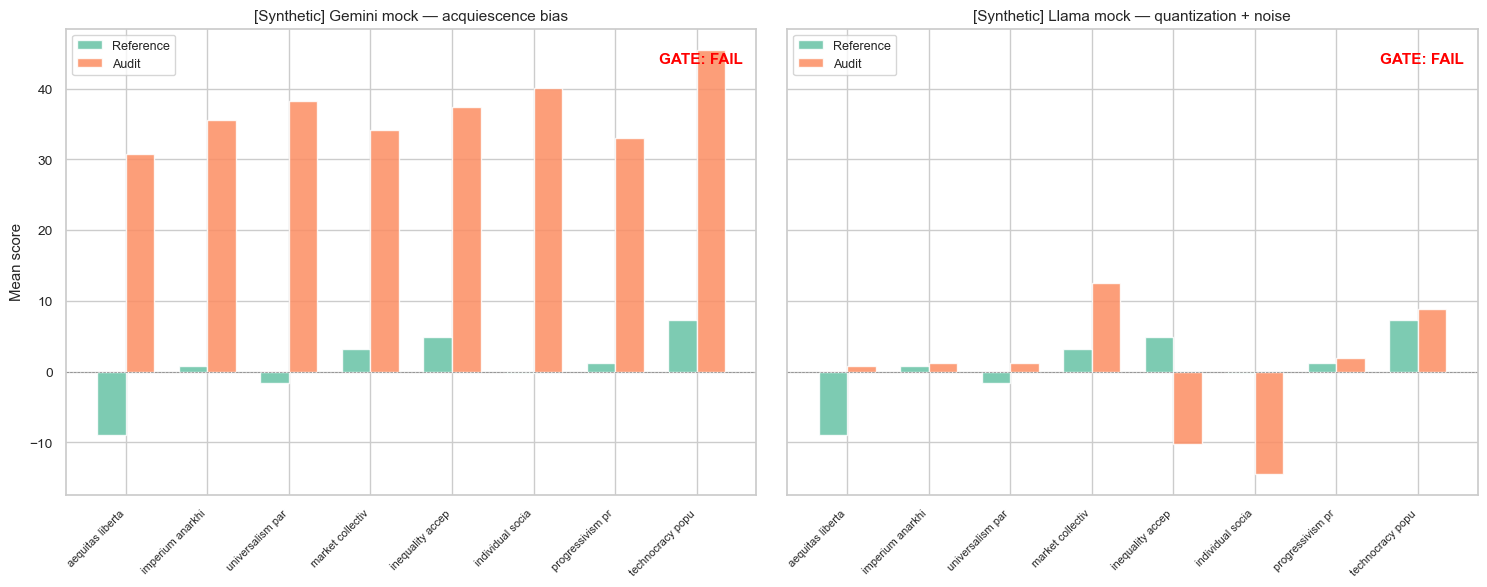

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

short_axes = [a.replace("axis_", "").replace("_", " ")[:16] for a in AXES]
x = np.arange(len(AXES))
width = 0.35

for ax, audit_df, title in [
    (ax1, gemini, "[Synthetic] Gemini mock — acquiescence bias"),
    (ax2, llama, "[Synthetic] Llama mock — quantization + noise"),
]:
    merged = ref.merge(audit_df, on="item_id")
    ref_means = [merged[f"{a}_mean"].mean() for a in AXES]
    audit_means = [merged[f"{a}_ollama"].mean() for a in AXES]

    ax.bar(x - width/2, ref_means, width, label="Reference", color="#66c2a5", alpha=0.85)
    ax.bar(x + width/2, audit_means, width, label="Audit", color="#fc8d62", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(short_axes, rotation=45, ha="right", fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.text(0.98, 0.95, "GATE: FAIL", transform=ax.transAxes,
            ha="right", va="top", fontsize=11, color="red", fontweight="bold")

ax1.set_ylabel("Mean score")
fig.set_tight_layout(True)
plt.show()

### What the triangulation reveals

- **Gemini mock (acquiescence bias)**: every axis score is inflated. The bias is systematic — a consistent positive offset per axis. This is *correctable*: subtract the per-axis mean difference and re-evaluate. After calibration, the adjusted labels may pass the gate.

- **Llama mock (quantization + noise)**: the model struggles with continuous scoring. Scores cluster at round numbers with high run-to-run variance. This is *not correctable* by simple offset adjustment — it reflects a model that cannot reliably perform the task.

- **The gate diagnoses the failure mode**, not just pass/fail. MAE catches the systematic shift (Gemini); directional agreement catches the noise (Llama). This tells the practitioner *what calibration to attempt*.

**When cross-model audit is unavailable**: the within-model reliability pipeline (ICC filtering, sign agreement) catches instability but cannot detect systematic bias. Together, within-model cleaning + cross-model audit form the full validation protocol.

---

## Compare Your Results

After running the pipeline on your own data, load your results here alongside the reference outputs to spot differences.

In [7]:
# ── Uncomment and update paths to compare your results ──

# my_labels = pd.read_parquet("path/to/your/labels_clean.parquet")
# my_items = pd.read_csv("path/to/your/proposals.csv")

# # Quick comparison: your valid rate vs reference
# my_valid = my_labels["valid"].sum() if "valid" in my_labels.columns else len(my_labels)
# print(f"Your data:      {my_valid} / {len(my_labels)} valid ({100*my_valid/len(my_labels):.0f}%)")
# print(f"Reference data: {n_valid} / {len(labels)} valid ({100*n_valid/len(labels):.0f}%)")

# # Side-by-side correlation heatmaps
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
# visualize.correlation_heatmap(labels, ax=ax1)
# ax1.set_title("Reference (synthetic)")
# visualize.correlation_heatmap(my_labels, ax=ax2)
# ax2.set_title("Your data")
# plt.show()

# # Side-by-side category centroids
# my_centroids = category_centroids(my_labels, my_items, category_col="category")
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
# visualize.category_centroids_line(centroids, ax=ax1)
# ax1.set_title("Reference (synthetic)")
# visualize.category_centroids_line(my_centroids, ax=ax2)
# ax2.set_title("Your data")
# plt.show()

print("Uncomment the cells above after running the pipeline on your own data.")

Uncomment the cells above after running the pipeline on your own data.


---

## Where to Go from Here

| Goal | Resource |
|------|----------|
| **Score your own proposals** | `prompts/README.md` and `scripts/score_proposals.py` |
| **Run the full analysis pipeline** | `python cli.py --help` — subcommands: `clean`, `validate`, `dimensionality`, `insights`, `triangulate` |
| **Browse pre-computed reports** | `data/examples/reference_outputs/` — validation, dimensionality, and insights reports |
| **Step-by-step replication** | `docs/replication-guide.md` |
| **Prompt engineering for open-weight models** | `docs/prompt-engineering.md` |
| **Cross-model calibration protocol** | `docs/calibration-protocol.md` |

If you use this toolkit, we want to hear what you find — open an issue or see `CONTRIBUTING.md`.

In [8]:
import datetime
print(f"Python {sys.version.split()[0]}")
print(f"pandas {pd.__version__}, numpy {np.__version__}, matplotlib {plt.matplotlib.__version__}")
print(f"Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}")

Python 3.10.16
pandas 2.2.3, numpy 1.26.4, matplotlib 3.10.0
Generated: 2026-04-07 17:36
